## Load the Libraries

In [2]:
from google.colab import files
import pandas as pd
import numpy as np

## Import the file

In [3]:
uploaded = files.upload()

Saving clean_loans.csv to clean_loans.csv


In [4]:
df = pd.read_csv('clean_loans.csv')
df.head()

,borrower_id,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,...,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted,credit_score_bucket,dti_bucket,employment_tenure_flag
0,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,...,36,13.05,542.86,55.5,Paid Off,0,0,Poor,Very High,2 or more years
1,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,...,48,14.21,153.62,40.4,Default,138,1,Poor,High,2 or more years
2,BRW-0002,24,CO,High School,Full-Time,4,40188,543,Own,2,...,36,12.37,1492.59,70.5,Paid Off,0,0,Poor,Very High,2 or more years
3,BRW-0003,50,NC,Bachelor,Contract,22,41014,611,Mortgage,0,...,48,11.18,238.58,59.8,Default,34,1,Fair,Very High,2 or more years
4,BRW-0004,43,TX,High School,Full-Time,19,35036,701,Mortgage,2,...,36,9.66,359.61,44.1,Current,0,0,Good,High,2 or more years


In [5]:
# Check for missing values
print('Missing values')
print(df.isnull().sum())
# Check unique values in key columns
print("\nCredit Score Buckets:")
print(df['credit_score_bucket'].value_counts().sort_index())

print("\nDTI Buckets:")
print(df['dti_bucket'].value_counts().sort_index())


Missing values
borrower_id               0
age                       0
state                     0
education_level           0
employment_status         0
years_employed            0
annual_income             0
credit_score              0
home_ownership            0
dependents                0
existing_monthly_debt     0
loan_id                   0
application_date          0
loan_purpose              0
loan_ammount              0
term_months               0
interest_rate             0
monthly_payment           0
dti_ratio                 0
loan_status               0
days_delinquent           0
defaulted                 0
credit_score_bucket       0
dti_bucket                0
employment_tenure_flag    0
dtype: int64

Credit Score Buckets:
credit_score_bucket
Average       79
Excellent    231
Fair          93
Good          82
Poor         116
Name: count, dtype: int64

DTI Buckets:
dti_bucket
High         134
Low           48
Moderate     125
Unknown       23
Very High    271
Name: co

## 1.What is the overall default rate, and how does it break down by credit score range? Which credit score bucket has the highest default rate?

In [6]:
# Overall default rate
total_loans = len(df)
total_defaults = df['defaulted'].sum()
overall_default_rate = (total_defaults / total_loans) * 100

print("=" * 45)
print("        OVERALL DEFAULT RATE SUMMARY")
print("=" * 45)
print(f"  Total Loans Issued   : {total_loans}")
print(f"  Total Defaults       : {int(total_defaults)}")
print(f"  Non-Defaults         : {int(total_loans - total_defaults)}")
print(f"  Overall Default Rate : {overall_default_rate:.2f}%")
print(f"  Target Default Rate  : 12.00%")
print(f"  Variance from Target : +{overall_default_rate - 12:.2f}%")
print("=" * 45)

        OVERALL DEFAULT RATE SUMMARY
  Total Loans Issued   : 601
  Total Defaults       : 146
  Non-Defaults         : 455
  Overall Default Rate : 24.29%
  Target Default Rate  : 12.00%
  Variance from Target : +12.29%


In [11]:
# Default rate by credit score bucket
credit_score_analysis = df.groupby('credit_score_bucket').agg(
    Total_Loans    = ('defaulted', 'count'),
    Total_Defaults = ('defaulted', 'sum'),
).reset_index()

# Calculate default rate per bucket
credit_score_analysis['Default_Rate_%'] = (
    credit_score_analysis['Total_Defaults'] /
    credit_score_analysis['Total_Loans'] * 100
).round(2)

# Sort by credit score bucket
credit_score_analysis = credit_score_analysis.sort_values('credit_score_bucket')

# Highlight the highest default rate bucket
highest_default_bucket = credit_score_analysis.loc[
    credit_score_analysis['Default_Rate_%'].idxmax()
]

print("\n" + "=" * 55)
print("       DEFAULT RATE BY CREDIT SCORE BUCKET")
print("=" * 55)
print(credit_score_analysis.to_string(index=False))
print("=" * 55)
print(f"\n  Highest Default Rate Bucket : {highest_default_bucket['credit_score_bucket']}")
print(f"   Default Rate                : {highest_default_bucket['Default_Rate_%']}%")
print(f"   Total Loans in Bucket       : {int(highest_default_bucket['Total_Loans'])}")
print(f"   Total Defaults in Bucket    : {int(highest_default_bucket['Total_Defaults'])}")


       DEFAULT RATE BY CREDIT SCORE BUCKET
credit_score_bucket  Total_Loans  Total_Defaults  Default_Rate_%
            Average           79              22           27.85
          Excellent          231              27           11.69
               Fair           93              27           29.03
               Good           82              13           15.85
               Poor          116              57           49.14

  Highest Default Rate Bucket : Poor
   Default Rate                : 49.14%
   Total Loans in Bucket       : 116
   Total Defaults in Bucket    : 57


/tmp/ipykernel_5899/357921498.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


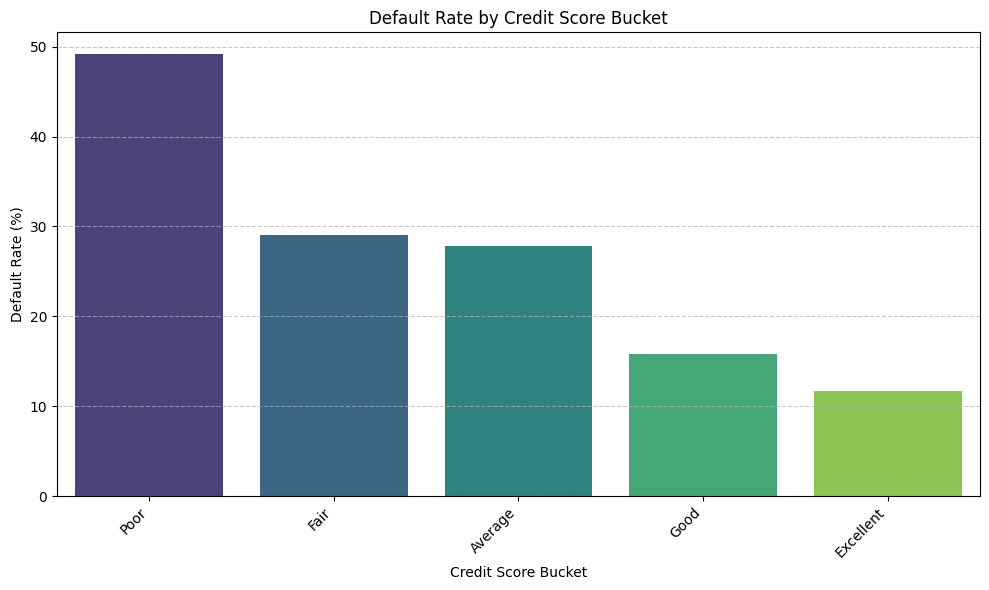

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x='credit_score_bucket',
    y='Default_Rate_%',
    data=credit_score_analysis.sort_values(by='Default_Rate_%', ascending=False),
    palette='viridis'
)

plt.title('Default Rate by Credit Score Bucket')
plt.xlabel('Credit Score Bucket')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 2.Is there a relationship between a borrower’s debt-to-income (DTI) ratio and the likelihood of defaulting? What DTI threshold would you recommend as a cutoff for loan approval?

In [19]:
# Default rate by DTI bucket
dti_analysis = df.groupby('dti_bucket').agg(
    Total_Loans    = ('defaulted', 'count'),
    Total_Defaults = ('defaulted', 'sum'),
).reset_index()

# Calculate default rate per bucket
dti_analysis['Default_Rate_%'] = (
    dti_analysis['Total_Defaults'] /
    dti_analysis['Total_Loans'] * 100
).round(2)

# Sort by DTI bucket (low to high)
dti_analysis = dti_analysis.sort_values('dti_bucket')

# Highlight the highest default rate bucket
highest_dti_default = dti_analysis.loc[
    dti_analysis['Default_Rate_%'].idxmax()
]

print("=" * 55)
print("        DEFAULT RATE BY DTI BUCKET")
print("=" * 55)
print(dti_analysis.to_string(index=False))
print("=" * 55)
print(f"\n  Highest Default Rate Bucket : {highest_dti_default['dti_bucket']}")
print(f"   Default Rate                : {highest_dti_default['Default_Rate_%']}%")
print(f"   Total Loans in Bucket       : {int(highest_dti_default['Total_Loans'])}")
print(f"   Total Defaults in Bucket    : {int(highest_dti_default['Total_Defaults'])}")

        DEFAULT RATE BY DTI BUCKET
dti_bucket  Total_Loans  Total_Defaults  Default_Rate_%
      High          134              29           21.64
       Low           48               8           16.67
  Moderate          125              14           11.20
   Unknown           23               2            8.70
 Very High          271              93           34.32

  Highest Default Rate Bucket : Very High
   Default Rate                : 34.32%
   Total Loans in Bucket       : 271
   Total Defaults in Bucket    : 93


/tmp/ipykernel_5899/1625636147.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


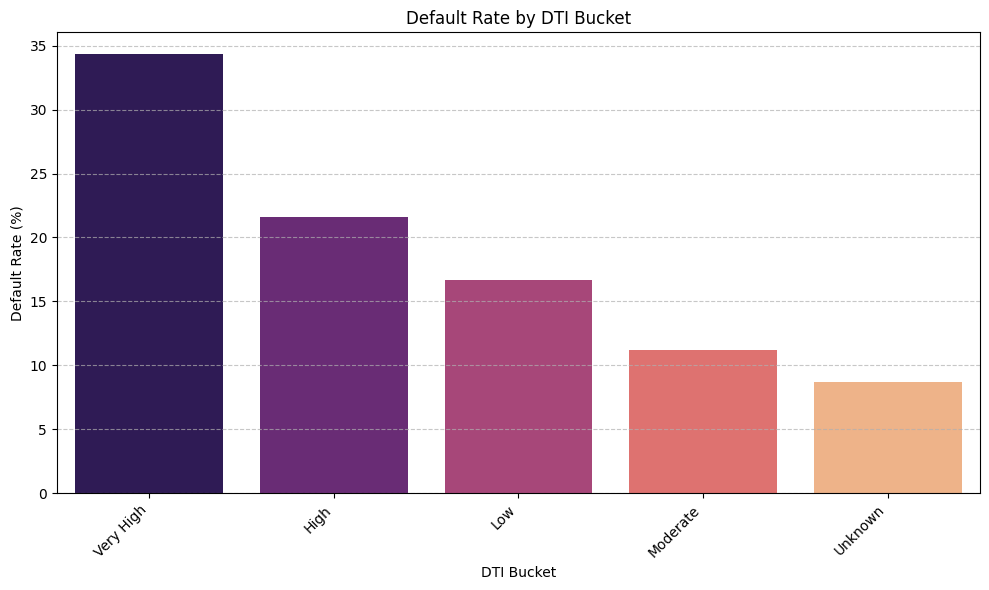

In [18]:
# Visualize Default Rate by DTI Bucket
plt.figure(figsize=(10, 6))
sns.barplot(
    x='dti_bucket',
    y='Default_Rate_%',
    data=dti_analysis.sort_values(by='Default_Rate_%', ascending=False),
    palette='magma'
)

plt.title('Default Rate by DTI Bucket')
plt.xlabel('DTI Bucket')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()